<a href="https://colab.research.google.com/github/chandraniraychowdhury5/DS/blob/main/AWH_data_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Water (L/hr) Energy (kWh/L) water generated per hour   energy require per liter of water production
#maximum production 32L/day

data = {
    "Temp":[18.74,22.16,24.63,28.81,33.08,35.52,37.00,36.12,33.93,30.46,26.09,23.35],
    "RH":[47.64,63.25,50.65,40.08,41.76,42.97,42.33,44.92,52.46,52.93,55.48,57.85],
    "Water":[0.13,0.95,0.67,0.26,0.22,0.29,0.32,0.36,0.36,0.30,0.26,0.20],
    "Energy":[1.98,0.84,1.25,2.68,3.47,2.47,2.42,2.10,2.10,2.35,2.50,2.89]
}
df = pd.DataFrame(data)
df['Power'] = df['Energy'] * df['Water']
print(df.head())

    Temp     RH  Water  Energy   Power
0  18.74  47.64   0.13    1.98  0.2574
1  22.16  63.25   0.95    0.84  0.7980
2  24.63  50.65   0.67    1.25  0.8375
3  28.81  40.08   0.26    2.68  0.6968
4  33.08  41.76   0.22    3.47  0.7634


In [2]:
print(df.describe())

            Temp         RH      Water     Energy      Power
count  12.000000  12.000000  12.000000  12.000000  12.000000
mean   29.157500  49.360000   0.360000   2.254167   0.690733
std     6.116794   7.281914   0.228115   0.696647   0.152818
min    18.740000  40.080000   0.130000   0.840000   0.257400
25%    24.310000  42.810000   0.250000   2.070000   0.685100
50%    29.635000  49.145000   0.295000   2.385000   0.736150
75%    34.327500  53.567500   0.360000   2.545000   0.766150
max    37.000000  63.250000   0.950000   3.470000   0.837500


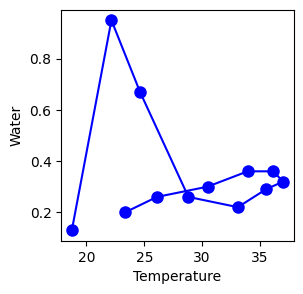

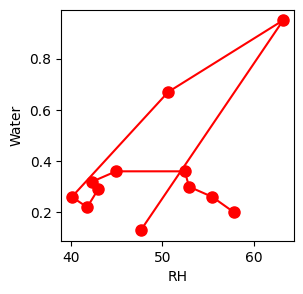

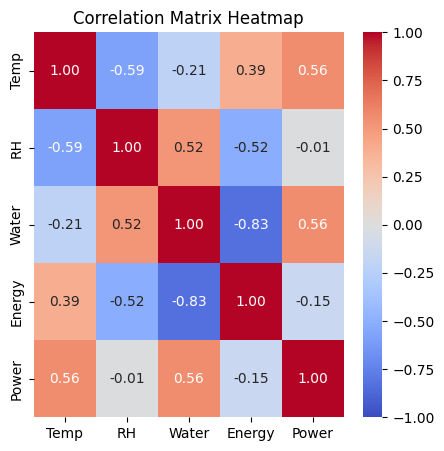

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (3,3))
plt.plot(df['Temp'],df['Water'], marker='o', markersize=8, color='blue', linestyle='-')
plt.xlabel('Temperature')
plt.ylabel('Water')
plt.show()

plt.figure(figsize = (3,3))
plt.plot(df['RH'],df['Water'], marker='o', markersize=8, color='red', linestyle='-')
plt.xlabel('RH')
plt.ylabel('Water')
plt.show()

corr_matrix = df.corr()

# 3. Create the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1
)

# 4. Display the plot
plt.title("Correlation Matrix Heatmap")
plt.show()



In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[['Temp', 'RH']]
y = df['Water']
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

weights = model.coef_
intercept = model.intercept_

temp = 31
RH = 60
data = poly.transform([[temp, RH]])
predicted_water = model.predict(data)
print(predicted_water)


[0.54524804]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [5]:
from scipy.interpolate import Rbf

rbf = Rbf(
    df['Temp'],
    df['RH'],
    df['Water'],
    function='multiquadric'
)

water = rbf(temp,RH)

print(water)

0.4543611794059004


In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor

gpr = GaussianProcessRegressor()
gpr.fit(X,y)
gpr.predict([[temp,RH]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


array([5.89708918e-11])

We used Leave-One-Out Cross-Validation (LOOCV) for validation. Since we have a total of 12 data points, the LOOCV approach trains the model on 11 data points to predict the remaining one. This process repeats for all 12 data points. Finally, the errors between the actual and predicted values are computed.

In [7]:
import numpy as np
import pandas as pd

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.interpolate import Rbf

df = pd.DataFrame({

    "Temp":[18.74,22.16,24.63,28.81,33.08,35.52,
            37.00,36.12,33.93,30.46,26.09,23.35],

    "RH":[47.64,63.25,50.65,40.08,41.76,42.97,
          42.33,44.92,52.46,52.93,55.48,57.85],

    "Water":[0.13,0.95,0.67,0.26,0.22,0.29,
             0.32,0.36,0.36,0.30,0.26,0.20]

})

X = df[['Temp','RH']].values
y = df['Water'].values

loo = LeaveOneOut()

pred_poly = []
pred_rbf = []
pred_gpr = []
actual = []

for train_idx, test_idx in loo.split(X):

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    # Polynomial Regression

    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ])

    poly_model.fit(X_train, y_train)

    p1 = poly_model.predict(X_test)[0]

    # RBF Interpolation

    rbf = Rbf(
        X_train[:,0],
        X_train[:,1],
        y_train,
        function='multiquadric'
    )

    p2 = rbf(
        X_test[0,0],
        X_test[0,1]
    )

    # Gaussian Process

    kernel = ConstantKernel(1.0) * RBF(length_scale=10)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        random_state=42
    )

    gpr.fit(X_train, y_train)

    p3 = gpr.predict(X_test)[0]


    actual.append(y_test[0])

    pred_poly.append(p1)
    pred_rbf.append(p2)
    pred_gpr.append(p3)

def evaluate(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return [name, mae, rmse, r2]

results = pd.DataFrame([

    evaluate("Polynomial", actual, pred_poly),

    evaluate("RBF", actual, pred_rbf),

    evaluate("Gaussian Process", actual, pred_gpr)

], columns=["Model","MAE","RMSE","R2"])

print(results)

print("\nPredictions")
pred_df = pd.DataFrame({

    "Actual":actual,
    "Polynomial":pred_poly,
    "RBF":pred_rbf,
    "Gaussian Process":pred_gpr

})

print(pred_df)

              Model       MAE      RMSE        R2
0        Polynomial  0.381760  0.613440 -6.889069
1               RBF  0.223793  0.373047 -1.917487
2  Gaussian Process  0.163636  0.238258 -0.190083

Predictions
    Actual  Polynomial                  RBF  Gaussian Process
0     0.13    1.461216   0.8629065547723842          0.380909
1     0.95   -0.445468  0.06890225280757334          0.306364
2     0.67   -0.040432  0.13878774754598577          0.331818
3     0.26    0.321707  0.19984224715963705          0.369091
4     0.22    0.331284  0.24272092254007305          0.372727
5     0.29    0.313121   0.2866621753187619          0.366364
6     0.32    0.333923  0.32230709289552806          0.363636
7     0.36    0.267713   0.3615342284061551          0.360000
8     0.36    0.226057   0.2733475298940009          0.360000
9     0.30    0.351599  0.41376584791825266          0.365455
10    0.26    0.465142  0.23123622400125488          0.369091
11    0.20    0.650998   0.4210550092813721

Conclusion: None of the models work, which is usual when using 12 data points. Moreover, data changes are also random. We should try other strategies.